# Classification d'images à l'aide d'algorithmes de Deep Learning

Projet n&#8239;$^\text{o}$ 6 du [cursus Machine Learning Engineer][2] d'OpenClassrooms

Auteur : [Kiril ISAKOV][1]

Mentor : Nicolas TISSERAND

Projet démarré le 23/03/2026

[1]: https://github.com/kirisakow/
[2]: https://openclassrooms.com/fr/paths/794-machine-learning-engineer

# Notebook de l'analyse et du prétraitement des images

## Imports et fonctions

In [ ]:
from functions_img_preprocessing import (
    apply_gaussian_blur,
    convert_to_grayscale,
    crop_image,
    equalize_histogram,
    get_boundingbox,
    get_breed,
    mirror_image,
    normalize_image,
    resize_image,
    rotate_image,
    whiten_image,
)
from lxml import etree
from pathlib import Path
from PIL import Image
import cv2
import glob
import numpy as np
import os
import pandas as pd

## Exemples de fonctions de *image preprocessing*

In [15]:
img_file_paths = sorted(Path('images/').glob('*/*.jpg'), key=lambda p: p.name)
annot_file_paths = sorted(Path('annotations/').glob('*/*'), key=lambda p: p.name)

In [16]:
for i, p in enumerate(img_file_paths):
    if '9379'.casefold() in p.as_posix().casefold():
        print(i, p)

14636 images/n02107142-Doberman/n02107142_9379.jpg
16501 images/n02109525-Saint_Bernard/n02109525_9379.jpg


Combien d'images :

In [17]:
display(
    f'{len(img_file_paths)} images',
    f'{len(annot_file_paths)} annotations',
)

'20580 images'

'20580 annotations'

In [18]:
random_doggo_index = 16501

In [19]:
display(
    get_breed(annot_file_paths[random_doggo_index]),
    get_boundingbox(annot_file_paths[random_doggo_index]),
)

'Saint_Bernard'

(72, 1, 467, 365)

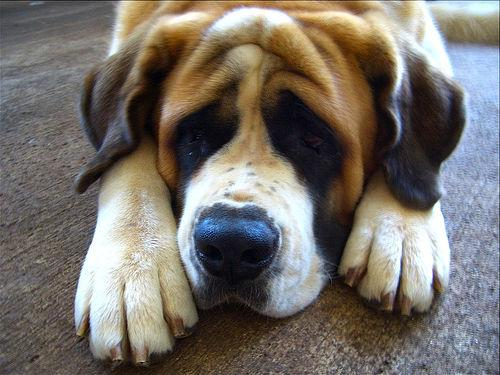

In [20]:
img = Image.open(img_file_paths[random_doggo_index])
img

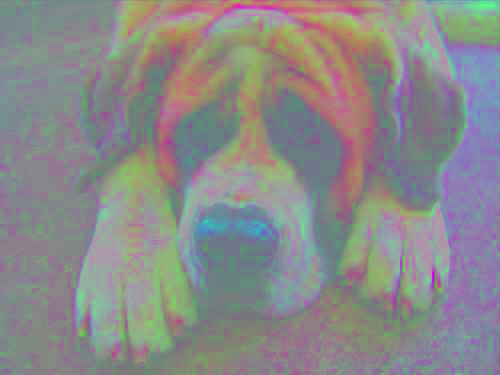

In [21]:
whiten_image(img)

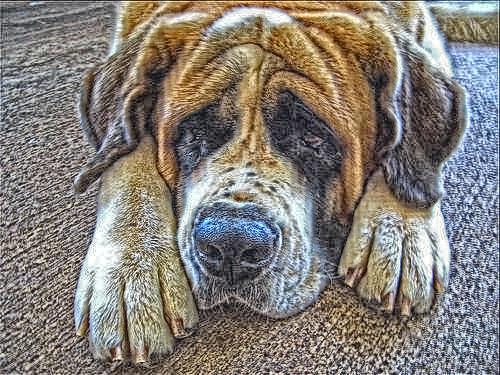

In [22]:
equalize_histogram(img, clip_limit=12.0, grid_size=(80, 80))

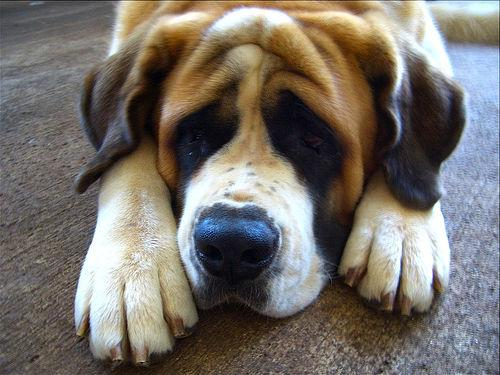

In [23]:
normalize_image(img, mean=0.0, std=1.0)

## Exemples de fonctions de *data augmentation*

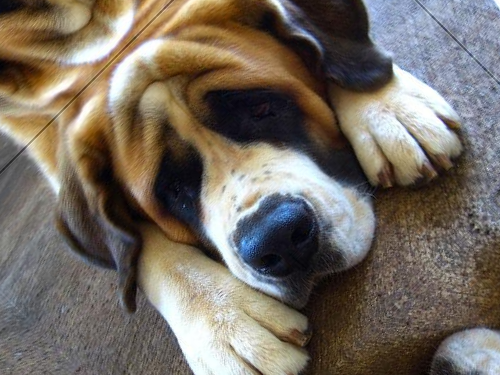

In [24]:
rotate_image(img, 45)

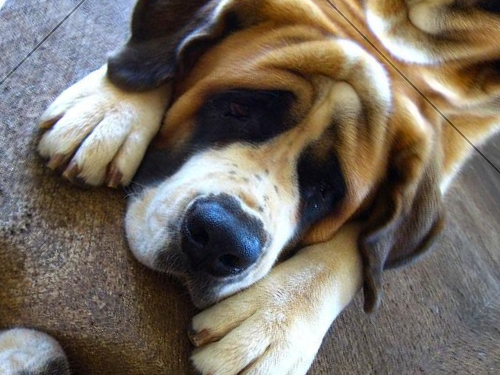

In [25]:
mirror_image(
    rotate_image(img, 45),
    horizontal=True
)